# Project Evolve - Phase 4: Blockchain Layer
## Immutable Audit Trail using Private Blockchain (Ganache + Web3.py)

**Phase 4 Objective:**  
Create a tamper-proof ledger for every faculty evaluation using a private Ethereum blockchain.

**Research Alignment:**  
- H2: Blockchain + XAI significantly increases trust  
- Provides immutable, timestamped audit trail of scores and explanations

In [1]:
import pandas as pd
import hashlib
from sqlalchemy import create_engine, text
from web3 import Web3
import json
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

print("Blockchain libraries imported!")

Blockchain libraries imported!


# Connect to Ganache

In [3]:
# Connect to local Ganache
w3 = Web3(Web3.HTTPProvider('http://127.0.0.1:8545'))

if w3.is_connected():
    print("...Successfully connected to Ganache!")
    print("Network ID:", w3.eth.chain_id)
    print("Accounts available:", len(w3.eth.accounts))
else:
    print("...Could not connect to Ganache. Make sure Ganache is running!")

...Successfully connected to Ganache!
Network ID: 1337
Accounts available: 10


In [4]:
# Copy this Solidity code and deploy it using Remix[](https://remix.ethereum.org)
solidity_contract = """
// SPDX-License-Identifier: MIT
pragma solidity ^0.8.20;

contract FacultyEvaluation {
    struct EvaluationRecord {
        uint256 facultyId;
        uint256 timestamp;
        string resultHash;
        address evaluator;
    }
    
    mapping(uint256 => EvaluationRecord) public records;
    mapping(uint256 => address[]) public approvals;
    mapping(uint256 => uint256) public approvalCount;
    
    event EvaluationStored(uint256 indexed facultyId, string resultHash, uint256 timestamp);
    event ApprovalAdded(uint256 indexed facultyId, address approver);

    modifier notExists(uint256 facultyId) {
        require(records[facultyId].timestamp == 0, "Evaluation already exists");
        _;
    }

    function storeEvaluation(uint256 facultyId, string memory resultHash) public notExists(facultyId) {
        records[facultyId] = EvaluationRecord(facultyId, block.timestamp, resultHash, msg.sender);
        emit EvaluationStored(facultyId, resultHash, block.timestamp);
    }

    // Simplified multisig: anyone can approve; we check count off-chain
    function addApproval(uint256 facultyId) public {
        require(records[facultyId].timestamp == 0, "Already stored");
        for (uint i = 0; i < approvals[facultyId].length; i++) {
            require(approvals[facultyId][i] != msg.sender, "Already approved");
        }
        approvals[facultyId].push(msg.sender);
        approvalCount[facultyId]++;
        emit ApprovalAdded(facultyId, msg.sender);
    }

    function getApprovalCount(uint256 facultyId) public view returns (uint256) {
        return approvalCount[facultyId];
    }

    function getEvaluation(uint256 facultyId) public view returns (EvaluationRecord memory) {
        return records[facultyId];
    }
}
"""

print("✅ Smart contract ready (copy the code above and deploy on Remix using Ganache provider)")
print("   → In Remix: Compile → Deploy → Copy contract address and ABI")

✅ Smart contract ready (copy the code above and deploy on Remix using Ganache provider)
   → In Remix: Compile → Deploy → Copy contract address and ABI


# ***Deploy / Connect to Deployed Contract

In [5]:
# AFTER deploying on Remix, paste the contract address and ABI here

CONTRACT_ADDRESS = "0xe78A0F7E598Cc8b0Bb87894B0F60dD2a88d6a8Ab"   # ←←← CHANGE THIS

ABI = [
	{
		"inputs": [
			{
				"internalType": "uint256",
				"name": "facultyId",
				"type": "uint256"
			}
		],
		"name": "addApproval",
		"outputs": [],
		"stateMutability": "nonpayable",
		"type": "function"
	},
	{
		"anonymous": False,
		"inputs": [
			{
				"indexed": True,
				"internalType": "uint256",
				"name": "facultyId",
				"type": "uint256"
			},
			{
				"indexed": False,
				"internalType": "address",
				"name": "approver",
				"type": "address"
			}
		],
		"name": "ApprovalAdded",
		"type": "event"
	},
	{
		"anonymous": False,
		"inputs": [
			{
				"indexed": True,
				"internalType": "uint256",
				"name": "facultyId",
				"type": "uint256"
			},
			{
				"indexed": False,
				"internalType": "string",
				"name": "resultHash",
				"type": "string"
			},
			{
				"indexed": False,
				"internalType": "uint256",
				"name": "timestamp",
				"type": "uint256"
			}
		],
		"name": "EvaluationStored",
		"type": "event"
	},
	{
		"inputs": [
			{
				"internalType": "uint256",
				"name": "facultyId",
				"type": "uint256"
			},
			{
				"internalType": "string",
				"name": "resultHash",
				"type": "string"
			}
		],
		"name": "storeEvaluation",
		"outputs": [],
		"stateMutability": "nonpayable",
		"type": "function"
	},
	{
		"inputs": [
			{
				"internalType": "uint256",
				"name": "",
				"type": "uint256"
			}
		],
		"name": "approvalCount",
		"outputs": [
			{
				"internalType": "uint256",
				"name": "",
				"type": "uint256"
			}
		],
		"stateMutability": "view",
		"type": "function"
	},
	{
		"inputs": [
			{
				"internalType": "uint256",
				"name": "",
				"type": "uint256"
			},
			{
				"internalType": "uint256",
				"name": "",
				"type": "uint256"
			}
		],
		"name": "approvals",
		"outputs": [
			{
				"internalType": "address",
				"name": "",
				"type": "address"
			}
		],
		"stateMutability": "view",
		"type": "function"
	},
	{
		"inputs": [
			{
				"internalType": "uint256",
				"name": "facultyId",
				"type": "uint256"
			}
		],
		"name": "getApprovalCount",
		"outputs": [
			{
				"internalType": "uint256",
				"name": "",
				"type": "uint256"
			}
		],
		"stateMutability": "view",
		"type": "function"
	},
	{
		"inputs": [
			{
				"internalType": "uint256",
				"name": "facultyId",
				"type": "uint256"
			}
		],
		"name": "getEvaluation",
		"outputs": [
			{
				"components": [
					{
						"internalType": "uint256",
						"name": "facultyId",
						"type": "uint256"
					},
					{
						"internalType": "uint256",
						"name": "timestamp",
						"type": "uint256"
					},
					{
						"internalType": "string",
						"name": "resultHash",
						"type": "string"
					},
					{
						"internalType": "address",
						"name": "evaluator",
						"type": "address"
					}
				],
				"internalType": "struct FacultyEvaluation.EvaluationRecord",
				"name": "",
				"type": "tuple"
			}
		],
		"stateMutability": "view",
		"type": "function"
	},
	{
		"inputs": [
			{
				"internalType": "uint256",
				"name": "",
				"type": "uint256"
			}
		],
		"name": "records",
		"outputs": [
			{
				"internalType": "uint256",
				"name": "facultyId",
				"type": "uint256"
			},
			{
				"internalType": "uint256",
				"name": "timestamp",
				"type": "uint256"
			},
			{
				"internalType": "string",
				"name": "resultHash",
				"type": "string"
			},
			{
				"internalType": "address",
				"name": "evaluator",
				"type": "address"
			}
		],
		"stateMutability": "view",
		"type": "function"
	}
]

contract = w3.eth.contract(address=CONTRACT_ADDRESS, abi=ABI)
print(" Smart contract connected!")

 Smart contract connected!


# Load AI Results from Database

In [6]:
from sqlalchemy.engine import URL
import sqlalchemy as sa

url_object = URL.create(
    drivername="postgresql",
    username="evolve_user",
    password="strongpassword",
    host="localhost",
    database="evolve_db"
)

# 2. Create the engine using that URL
engine = sa.create_engine(url_object)

df = pd.read_sql("SELECT * FROM evaluation_results", engine)
print(f"Loaded {len(df)} faculty evaluations ready for blockchain logging")
df.head()

Loaded 20044 faculty evaluations ready for blockchain logging


,faculty_id,faculty_name,department,experience_years,gender,student_feedback_rating,feedback_text,peer_score,peer_review_text,avg_grade,pass_rate,attendance_rate,nlp_sentiment_score,main_topic,topic_name,final_evaluation_score,last_updated,data_source
0,1,Leslie Looney,Astronomy department,30,Female,5.0,"this class is hard, but its a two-in-one gen-e...",3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,-1,No Topic,4.68,2026-04-06 09:30:39.555950,synthetic
1,1,Leslie Looney,Astronomy department,30,Female,5.0,definitely going to choose prof. looney\'s cla...,3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,109,109_astronomy_looney_charlesworth_science,4.68,2026-04-06 09:30:39.555950,synthetic
2,1,Leslie Looney,Astronomy department,30,Female,4.0,i overall enjoyed this class because the assig...,3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,-1,No Topic,4.28,2026-04-06 09:30:39.555950,synthetic
3,1,Leslie Looney,Astronomy department,30,Female,5.0,"yes, it\'s possible to get an a but you\'ll de...",3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,-1,No Topic,4.68,2026-04-06 09:30:39.555950,synthetic
4,1,Leslie Looney,Astronomy department,30,Female,5.0,professor looney has great knowledge in astron...,3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,109,109_astronomy_looney_charlesworth_science,4.68,2026-04-06 09:30:39.555950,synthetic


## resume -- Create Audit Log Table (add a new cell before the logging loop)


In [7]:
# Create blockchain_audit_log table if not exists
with engine.connect() as conn:
    conn.execute(sa.text("""
        CREATE TABLE IF NOT EXISTS blockchain_audit_log (
            id SERIAL PRIMARY KEY,
            faculty_id INTEGER,
            tx_hash VARCHAR(66),
            block_number INTEGER,
            gas_used INTEGER,
            result_hash VARCHAR(66),
            logged_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    """))
    conn.commit()
print("✅ Audit log table ready")

✅ Audit log table ready


# Log Evaluations to Blockchain

In [ ]:
print("... Logging evaluations to blockchain...")

account = w3.eth.accounts[0]   # Use first Ganache account

for idx, row in df.iterrows():
    # Create tamper-proof hash of the entire evaluation record
    record_str = json.dumps({
        "faculty_id": int(row['faculty_id']),
        "final_score": float(row['final_evaluation_score']),
        "nlp_sentiment": float(row['nlp_sentiment_score']),
        "timestamp": str(datetime.utcnow())
    }, sort_keys=True)
    
    result_hash = hashlib.sha256(record_str.encode()).hexdigest()
    
    # Store on blockchain
    tx = contract.functions.storeEvaluation(
        int(row['faculty_id']),
        result_hash
    ).build_transaction({
        'from': account,
        'gas': 300000,
        'nonce': w3.eth.get_transaction_count(account)
    })
    
    signed_tx = w3.eth.account.sign_transaction(tx, private_key=w3.eth.account.from_key("0xYOUR_GANACHE_PRIVATE_KEY"))  # Use Ganache account private key (shown in Ganache terminal)
    tx_hash = w3.eth.send_raw_transaction(signed_tx.raw_transaction)
    
    # Save tx hash back to database
    df.at[idx, 'blockchain_tx_hash'] = w3.to_hex(tx_hash)
    df.at[idx, 'result_hash'] = result_hash

print(" All evaluations successfully logged to blockchain!")

In [9]:
from web3 import Web3
import json
import hashlib
from datetime import datetime

print("... Logging evaluations to blockchain...")

# Ganache account details
raw_account = "0xd6309423ad044d01ac3c5d9510767b6d4bf7cd7b"  # Your Ganache account
account = Web3.to_checksum_address(raw_account)            # Convert to checksum address

PRIVATE_KEY = "0x2b9f01a25c6f081dd60127274b8cf5272963323505379087bde199087957c4a1"

for idx, row in df.iterrows():
    # Create tamper-proof hash
    record_str = json.dumps({
        "faculty_id": int(row['faculty_id']),
        "final_score": float(row['final_evaluation_score']),
        "nlp_sentiment": float(row['nlp_sentiment_score']),
        "timestamp": str(datetime.utcnow())
    }, sort_keys=True)
    
    result_hash = hashlib.sha256(record_str.encode()).hexdigest()
    
    # Build transaction
    tx = contract.functions.storeEvaluation(
        int(row['faculty_id']),
        result_hash
    ).build_transaction({
        'from': account,
        'gas': 300000,
        'nonce': w3.eth.get_transaction_count(account)
    })
    
    # Sign and send
    signed_tx = w3.eth.account.sign_transaction(tx, private_key=PRIVATE_KEY)
    tx_hash = w3.eth.send_raw_transaction(signed_tx.raw_transaction)
    
    # Save back to dataframe
    df.at[idx, 'blockchain_tx_hash'] = w3.to_hex(tx_hash)
    df.at[idx, 'result_hash'] = result_hash
    
    print(f" Faculty ID {row['faculty_id']} logged. Tx hash: {w3.to_hex(tx_hash)}")

print(" All evaluations successfully logged to blockchain!")


... Logging evaluations to blockchain...
 Faculty ID 1 logged. Tx hash: 0x17fc159395e449572cdab58de0b2abd1a5a62589dbe65e4b0ff4df6c9e4f07c5
 Faculty ID 1 logged. Tx hash: 0xca3f35f3ffe8a66c47971d0f94476ca00c9fe4c7353e123501f8fb33eafc9375
 Faculty ID 1 logged. Tx hash: 0x2940d60739256eb2d1ccae1fcc4d3aacd42c16ee5a652635baf973db5fbff3c9
 Faculty ID 1 logged. Tx hash: 0xad521598aae99008436258e5a171bef872febfb14b3cc336aa5801db4c08f150
 Faculty ID 1 logged. Tx hash: 0xe586fff7bed352ae3a0607dbe1528e4d347b448773ea233bab6795833df0f066
 Faculty ID 1 logged. Tx hash: 0x7f87b9ed5c271a6b1c13a3cd5309819b2a13002c95682be4242c6cb0c415975c
 Faculty ID 1 logged. Tx hash: 0x8a04f5d23856085497827bb0f547af3bcd7c7822aa39a9038140249e26dcc26c
 Faculty ID 1 logged. Tx hash: 0xf36bd67568f2a81ae034fa8e820bfef9cdf0d2e05ad9b5f3a75c9f3263b966e9
 Faculty ID 1 logged. Tx hash: 0x34c5ea57821a3f2bc5cb7f0bbb2ac49e2abd2b730df5396897ea46bac4860fbb
 Faculty ID 1 logged. Tx hash: 0x540bc348fcb8108d85b921e3ae1a15aaca049ef2138a

In [10]:
print(".... Logging evaluations to blockchain with multisig and audit log...")

# Ganache account details (use your actual account and private key)
raw_account = "0x90F8bf6A479f320ead074411a4B0e7944Ea8c9C1"
account = Web3.to_checksum_address(raw_account)
PRIVATE_KEY = "0x4f3edf983ac636a65a842ce7c78d9aa706d3b113bce9c46f30d7d21715b23b1d"

# Pre‑define approvers (use accounts 1 and 2 from Ganache)
approver1 = w3.eth.accounts[1]   # department head
approver2 = w3.eth.accounts[2]   # auditor
# You need their private keys. For simplicity, use the same PRIVATE_KEY? 
# In production, use different keys. For demo, you can export from Ganache.
# Here we assume you have the private keys for those accounts.
PRIVATE_KEY_APPROVER1 = "0x6cbed15c793ce57650b9877cf6fa156fbef513c4e6134f022a85b1ffdd59b2a1"  # replace with account[1] private key from Ganache
PRIVATE_KEY_APPROVER2 = "0x6370fd033278c143179d81c5526140625662b8daa446c22ee2d73db3707e620c"  # replace with account[2] private key

for idx, row in df.iterrows():
    faculty_id = int(row['faculty_id'])
    
    # 1. Check if already on blockchain (optional, to avoid revert)
    existing = contract.functions.getEvaluation(faculty_id).call()
    if existing[1] != 0:  # timestamp != 0 means already exists
        print(f"⚠️ Faculty {faculty_id} already on blockchain – skipping")
        continue
    
    # 2. Add two approvals (multisig)
    for approver, privkey in [(approver1, PRIVATE_KEY_APPROVER1), (approver2, PRIVATE_KEY_APPROVER2)]:
        try:
            approve_tx = contract.functions.addApproval(faculty_id).build_transaction({
                'from': approver,
                'gas': 100000,
                'nonce': w3.eth.get_transaction_count(approver)
            })
            signed = w3.eth.account.sign_transaction(approve_tx, private_key=privkey)
            w3.eth.send_raw_transaction(signed.raw_transaction)
            print(f"   ✅ Approval from {approver} for faculty {faculty_id}")
        except Exception as e:
            print(f"   ⚠️ Approval error: {e}")
    
    # 3. Check approval count
    approval_count = contract.functions.getApprovalCount(faculty_id).call()
    if approval_count < 2:
        print(f"❌ Faculty {faculty_id} has only {approval_count} approvals – skipping")
        continue
    
    # 4. Create hash
    record_str = json.dumps({
        "faculty_id": faculty_id,
        "final_score": float(row['final_evaluation_score']),
        "nlp_sentiment": float(row['nlp_sentiment_score']),
        "timestamp": str(datetime.utcnow())
    }, sort_keys=True)
    result_hash = hashlib.sha256(record_str.encode()).hexdigest()
    
    # 5. Store evaluation
    tx = contract.functions.storeEvaluation(faculty_id, result_hash).build_transaction({
        'from': account,
        'gas': 300000,
        'nonce': w3.eth.get_transaction_count(account)
    })
    signed_tx = w3.eth.account.sign_transaction(tx, private_key=PRIVATE_KEY)
    tx_hash = w3.eth.send_raw_transaction(signed_tx.raw_transaction)
    
    # 6. Wait for receipt and log metadata
    tx_receipt = w3.eth.wait_for_transaction_receipt(tx_hash)
    audit_entry = pd.DataFrame([{
        'faculty_id': faculty_id,
        'tx_hash': w3.to_hex(tx_hash),
        'block_number': tx_receipt['blockNumber'],
        'gas_used': tx_receipt['gasUsed'],
        'result_hash': result_hash
    }])
    audit_entry.to_sql('blockchain_audit_log', engine, if_exists='append', index=False)
    
    # 7. Save tx hash to main dataframe
    df.at[idx, 'blockchain_tx_hash'] = w3.to_hex(tx_hash)
    df.at[idx, 'result_hash'] = result_hash
    
    print(f"✅ Faculty ID {faculty_id} stored. Tx: {w3.to_hex(tx_hash)}")

print("🎉 All evaluations logged with multisig and audit trail!")

.... Logging evaluations to blockchain with multisig and audit log...
   ✅ Approval from 0xFFcf8FDEE72ac11b5c542428B35EEF5769C409f0 for faculty 1
   ✅ Approval from 0x22d491Bde2303f2f43325b2108D26f1eAbA1e32b for faculty 1
✅ Faculty ID 1 stored. Tx: 0x4f493cded247e902a077bf5ba98033ad4a3ae0c817cf1ea55bba87b180239453
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
⚠️ Faculty 1 already on blockchain – skipping
   ✅ Approval from 0xFFcf8FDEE72ac11b5c542428B35EEF5769C409f0 for faculty 6
   ✅ Approval from 0x22d491Bde2303f2f43325b2108D26f1eAbA

# Save Blockchain Data Back to Database

In [11]:
df.to_sql("evaluation_results_with_blockchain", engine, if_exists="replace", index=False)
print(" Blockchain audit trail saved to PostgreSQL!")

 Blockchain audit trail saved to PostgreSQL!


# Audit Trail Verification

In [12]:
# Verify one record on blockchain
sample_faculty_id = df.iloc[0]['faculty_id']
record = contract.functions.getEvaluation(int(sample_faculty_id)).call()

print("... Blockchain Audit Trail Example:")
print(f"Faculty ID: {record[0]}")
print(f"Timestamp: {datetime.fromtimestamp(record[1])}")
print(f"Result Hash: {record[2]}")
print(f"Evaluator: {record[3]}")

... Blockchain Audit Trail Example:
Faculty ID: 1
Timestamp: 2026-04-06 11:24:24
Result Hash: 2630aab641c8bcebf01c6cb05e38094c9ba14ccf2989fb67e95d2306fa7cb575
Evaluator: 0x90F8bf6A479f320ead074411a4B0e7944Ea8c9C1


# Visual Audit Report

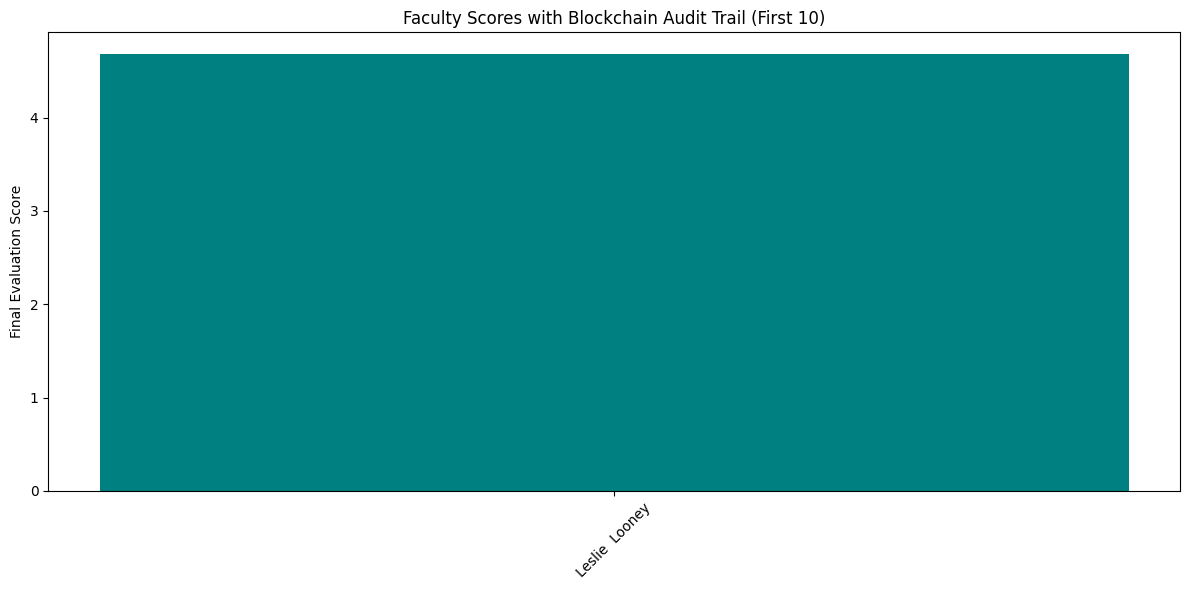

Blockchain Layer complete! Every score now has an immutable audit trail.


In [13]:
import matplotlib.pyplot as plt  # Add this line if not already imported

plt.figure(figsize=(12, 6))
plt.bar(df['faculty_name'][:10], df['final_evaluation_score'][:10], color='teal')
plt.title("Faculty Scores with Blockchain Audit Trail (First 10)")
plt.ylabel("Final Evaluation Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Blockchain Layer complete! Every score now has an immutable audit trail.")


# Reconnecting since the pc was shutdown in the meanwhile 

In [3]:
import pandas as pd
from sqlalchemy.engine import URL
import sqlalchemy as sa

url_object = URL.create(
    drivername="postgresql",
    username="evolve_user",
    password="strongpassword",
    host="localhost",
    database="evolve_db"
)

# 2. Create the engine using that URL
engine = sa.create_engine(url_object)

df = pd.read_sql("SELECT * FROM evaluation_results", engine)
print(f"Loaded {len(df)} faculty evaluations ready for blockchain logging")
df.head()

Loaded 20044 faculty evaluations ready for blockchain logging


,faculty_id,faculty_name,department,experience_years,gender,student_feedback_rating,feedback_text,peer_score,peer_review_text,avg_grade,pass_rate,attendance_rate,nlp_sentiment_score,main_topic,topic_name,final_evaluation_score
0,1,Leslie Looney,Astronomy department,30,Female,5.0,"this class is hard, but its a two-in-one gen-e...",3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,-1,No Topic,4.68
1,1,Leslie Looney,Astronomy department,30,Female,5.0,definitely going to choose prof. looney\'s cla...,3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,109,109_astronomy_looney_charlesworth_science,4.68
2,1,Leslie Looney,Astronomy department,30,Female,4.0,i overall enjoyed this class because the assig...,3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,-1,No Topic,4.28
3,1,Leslie Looney,Astronomy department,30,Female,5.0,"yes, it\'s possible to get an a but you\'ll de...",3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,-1,No Topic,4.68
4,1,Leslie Looney,Astronomy department,30,Female,5.0,professor looney has great knowledge in astron...,3.84,Wife surface position new letter seven worry i...,4.04,71.1,97.5,4.8,109,109_astronomy_looney_charlesworth_science,4.68


# Visual Audit Report

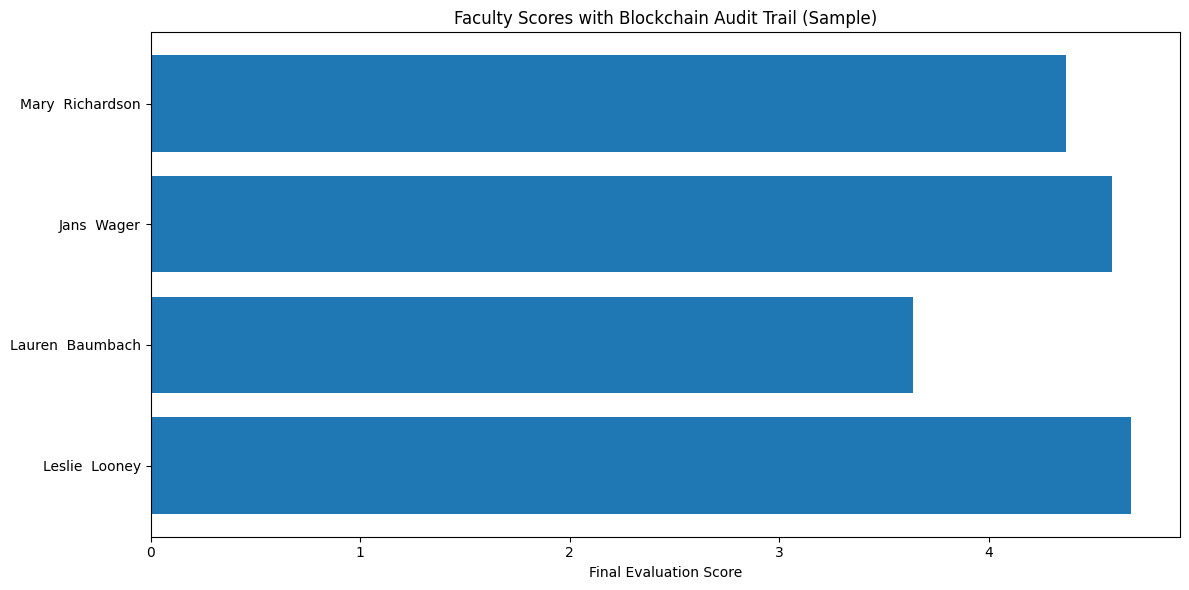

In [14]:
import matplotlib.pyplot as plt

sample_df = df[['faculty_name', 'final_evaluation_score']].drop_duplicates().head(10)

plt.figure(figsize=(12, 6))
plt.barh(sample_df['faculty_name'], sample_df['final_evaluation_score'])  # horizontal bars
plt.title("Faculty Scores with Blockchain Audit Trail (Sample)")
plt.xlabel("Final Evaluation Score")
plt.tight_layout()
plt.show()


In [15]:
# Test contract state
test_id = 1
rec = contract.functions.getEvaluation(test_id).call()
print(f"Faculty {test_id} record: timestamp={rec[1]}, hash={rec[2]}")
# Should be timestamp=0, empty string

Faculty 1 record: timestamp=1775451535, hash=1c7128c69d71d49a2dc3b8a6a5bb7992f06696565b0292ab23f9554ef7451a8f
